<a href="https://colab.research.google.com/github/sienaro/manipTester/blob/main/manipCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers datasets scikit-learn torch -q

In [2]:
import urllib.request

url_maj = "https://raw.githubusercontent.com/audreycs/MentalManip/main/mentalmanip_dataset/mentalmanip_maj.csv"
url_con = "https://raw.githubusercontent.com/audreycs/MentalManip/main/mentalmanip_dataset/mentalmanip_con.csv"

urllib.request.urlretrieve(url_maj, "mentalmanip_maj.csv")
urllib.request.urlretrieve(url_con, "mentalmanip_con.csv")
print("Downloaded!")

Downloaded!


In [3]:
import csv

def load_mentalmanip(filepath):
    data = []
    with open(filepath, 'r', newline='', encoding='utf-8') as f:
        reader = csv.reader(f, delimiter=',', quoting=csv.QUOTE_MINIMAL)
        header = next(reader)
        print(f"Columns: {header}")
        dialogue_col = next(i for i, h in enumerate(header) if 'dialogue' in h.lower())
        label_col    = next(i for i, h in enumerate(header) if 'manipulative' in h.lower())
        for row in reader:
            if len(row) > max(dialogue_col, label_col):
                text = row[dialogue_col].strip()
                try:
                    label = int(row[label_col].strip())
                    if text:
                        data.append((text, label))
                except ValueError:
                    continue
    return data

data = load_mentalmanip("mentalmanip_maj.csv")
print(f"\nLoaded {len(data)} dialogues")

Columns: ['ID', 'Dialogue', 'Manipulative', 'Technique', 'Vulnerability']

Loaded 4000 dialogues


In [5]:
from collections import Counter

texts  = [t for t, _ in data]
labels = [l for _, l in data]
counts = Counter(labels)

In [6]:
from sklearn.model_selection import train_test_split

SEED = 42

X_tmp, X_test, y_tmp, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=SEED, stratify=labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.125, random_state=SEED, stratify=y_tmp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Train class dist: {Counter(y_train)}")
print(f"Test  class dist: {Counter(y_test)}")

Train: 2800 | Val: 400 | Test: 800
Train class dist: Counter({1: 1972, 0: 828})
Test  class dist: Counter({1: 564, 0: 236})


In [8]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, classification_report, confusion_matrix
)

def evaluate(y_true, y_pred, y_prob=None, name="Model"):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Accuracy:        {accuracy_score(y_true, y_pred):.4f}")
    print(f"Macro F1:        {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Precision (mac): {precision_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Recall (mac):    {recall_score(y_true, y_pred, average='macro'):.4f}")
    if y_prob is not None:
        print(f"ROC-AUC:         {roc_auc_score(y_true, y_prob):.4f}")
    print(f"\nConfusion matrix (rows=true, cols=pred):")
    print(confusion_matrix(y_true, y_pred))
    print(f"\n{classification_report(y_true, y_pred, target_names=['Non-manip', 'Manipulative'])}")
    return {
        "name": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average='macro'),
        "roc_auc": roc_auc_score(y_true, y_prob) if y_prob is not None else None,
    }

results = {}
print("Evaluation helper ready.")

Evaluation helper ready.


In [9]:
from collections import Counter

majority_class = Counter(y_train).most_common(1)[0][0]
print(f"Majority class: {majority_class} ({'Manipulative' if majority_class == 1 else 'Non-manipulative'})")

y_pred_majority = [majority_class] * len(y_test)

results["majority"] = evaluate(y_true=y_test, y_pred=y_pred_majority, name="Majority Class Baseline")

Majority class: 1 (Manipulative)

  Majority Class Baseline
Accuracy:        0.7050
Macro F1:        0.4135
Precision (mac): 0.3525
Recall (mac):    0.5000

Confusion matrix (rows=true, cols=pred):
[[  0 236]
 [  0 564]]

              precision    recall  f1-score   support

   Non-manip       0.00      0.00      0.00       236
Manipulative       0.70      1.00      0.83       564

    accuracy                           0.70       800
   macro avg       0.35      0.50      0.41       800
weighted avg       0.50      0.70      0.58       800



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Weighted to handle class imbalance
class_weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
weight_dict = {0: class_weights[0], 1: class_weights[1]}

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

clf = LogisticRegression(class_weight=weight_dict, max_iter=1000, random_state=SEED)
clf.fit(X_train_vec, y_train)

y_pred_lr = clf.predict(X_test_vec)
y_prob_lr  = clf.predict_proba(X_test_vec)[:, 1]

results["tfidf_lr"] = evaluate(y_test, y_pred_lr, y_prob_lr, name="TF-IDF + Logistic Regression")


  TF-IDF + Logistic Regression
Accuracy:        0.6925
Macro F1:        0.6398
Precision (mac): 0.6370
Recall (mac):    0.6439
ROC-AUC:         0.6952

Confusion matrix (rows=true, cols=pred):
[[124 112]
 [134 430]]

              precision    recall  f1-score   support

   Non-manip       0.48      0.53      0.50       236
Manipulative       0.79      0.76      0.78       564

    accuracy                           0.69       800
   macro avg       0.64      0.64      0.64       800
weighted avg       0.70      0.69      0.70       800



In [11]:
feature_names = vectorizer.get_feature_names_out()
coefs = clf.coef_[0]

top_manip     = [feature_names[i] for i in coefs.argsort()[-15:][::-1]]
top_non_manip = [feature_names[i] for i in coefs.argsort()[:15]]

print("Top tokens predicting MANIPULATIVE:")
print(top_manip)
print("\nTop tokens predicting NON-MANIPULATIVE:")
print(top_non_manip)

Top tokens predicting MANIPULATIVE:
['you re', 'stop', 'get', 'person1 you', 'this', 're', 'you', 'nothing', 'what you', 'not', 'no', 'to me', 'can', 'just', 'if you']

Top tokens predicting NON-MANIPULATIVE:
['don remember', 'yes', 'remember', 'he', 'sure', 'crazy', 'well', 'person1 tell', 'from me', 'went', 'waiting', 'person2 yes', 'girl', 'crazy person2', 'thank']


In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import numpy as np

class DialogueDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

print("Dataset class defined.")

Dataset class defined.


In [13]:
MODEL_NAME = "bert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)
print(f"Loaded {MODEL_NAME}")

Device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded bert-base-uncased


In [14]:
from sklearn.utils.class_weight import compute_class_weight

BATCH_SIZE = 16

train_dataset = DialogueDataset(X_train, y_train, tokenizer)
val_dataset   = DialogueDataset(X_val,   y_val,   tokenizer)
test_dataset  = DialogueDataset(X_test,  y_test,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

# Weighted loss for class imbalance
class_weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
weights = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights)

print(f"Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")
print(f"Class weights: non-manip={class_weights[0]:.3f}, manipulative={class_weights[1]:.3f}")

Batches — Train: 175 | Val: 25 | Test: 50
Class weights: non-manip=1.691, manipulative=0.710


In [ ]:
from sklearn.metrics import f1_score

EPOCHS = 3
LR     = 2e-5

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

best_val_f1    = 0
best_model_state = None

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    # ── Validate ──
    model.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_true.extend(batch['labels'].numpy())

    val_f1 = f1_score(val_true, val_preds, average='macro')
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS}  loss={avg_loss:.4f}  val_macro_f1={val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  ↑ new best — saving checkpoint")

print(f"\nTraining done. Best val F1: {best_val_f1:.4f}")

Epoch 1/3  loss=0.6661  val_macro_f1=0.5919
  ↑ new best — saving checkpoint
Epoch 2/3  loss=0.5857  val_macro_f1=0.6560
  ↑ new best — saving checkpoint
Epoch 3/3  loss=0.4655  val_macro_f1=0.6654
  ↑ new best — saving checkpoint

Training done. Best val F1: 0.6654


In [ ]:
model.load_state_dict(best_model_state)
model.eval()

test_preds, test_true, test_probs = [], [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        preds   = (probs >= 0.5).astype(int)
        test_preds.extend(preds)
        test_true.extend(batch['labels'].numpy())
        test_probs.extend(probs)

results["bert"] = evaluate(test_true, test_preds, test_probs, name="Fine-tuned BERT")


  Fine-tuned BERT
Accuracy:        0.6900
Macro F1:        0.6385
Precision (mac): 0.6354
Recall (mac):    0.6434
ROC-AUC:         0.7439

Confusion matrix (rows=true, cols=pred):
[[125 111]
 [137 427]]

              precision    recall  f1-score   support

   Non-manip       0.48      0.53      0.50       236
Manipulative       0.79      0.76      0.77       564

    accuracy                           0.69       800
   macro avg       0.64      0.64      0.64       800
weighted avg       0.70      0.69      0.69       800



In [ ]:
model.save_pretrained("/content/saved_model")
tokenizer.save_pretrained("/content/saved_model")
print("Model saved to /content/saved_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/saved_model


In [ ]:
!wget -q https://data.millercenter.org/miller_center_speeches.tgz
!tar -xzf miller_center_speeches.tgz
!ls speeches/ | head -5
print("Done! Speech files downloaded.")

Abraham_Lincoln_1852-07-06T13:03:58-04:56_July_6,_1852:_Eulogy_on_Henry_Clay.json
Abraham_Lincoln_1854-10-16T13:03:58-04:56_October_16,_1854:_At_Peoria,_Illinois.json
Abraham_Lincoln_1858-06-16T13:03:58-04:56_June_16,_1858:_"A_House_Divided"_Speech.json
Abraham_Lincoln_1860-02-27T13:03:58-04:56_February_27,_1860:_Cooper_Union_Address.json
Abraham_Lincoln_1861-02-11T13:03:58-04:56_February_11,_1861:_Farewell_Address.json
Done! Speech files downloaded.


In [ ]:
import json, os, glob

speech_files = glob.glob("speeches/*.json")
print(f"Total speeches: {len(speech_files)}")

# Load all speeches
speeches = []
for path in speech_files:
    with open(path, 'r', encoding='utf-8') as f:
        speeches.append(json.load(f))

# Peek at structure
print(f"\nKeys in each speech: {list(speeches[0].keys())}")
print(f"\nExample:")
print(f"  President: {speeches[0].get('president', speeches[0].get('speaker', 'N/A'))}")
print(f"  Title:     {speeches[0].get('title', 'N/A')}")
print(f"  Date:      {speeches[0].get('date', 'N/A')}")
print(f"  Text (first 200 chars): {speeches[0].get('transcript', speeches[0].get('text', ''))[:200]}")

Total speeches: 1057

Keys in each speech: ['title', 'doc_name', 'url', 'date', 'transcript', 'transcript_html', 'president', 'video', 'audio', 'introduction']

Example:
  President: Barack Obama
  Title:     March 1, 2013: Statement on the Government Sequester
  Date:      2013-03-01T01:00:00-05:00
  Text (first 200 chars): Good morning, everybody.&nbsp; As you know, I just met with leaders of both parties to discuss a way forward in light of the severe budget cuts that start to take effect today.&nbsp; I told them these


In [ ]:
import random
random.seed(42)

def chunk_speech(text, chunk_size=80, overlap=10):
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunks.append(" ".join(words[start:end]))
        if end == len(words):
            break
        start += chunk_size - overlap
    return chunks

# Build a flat list of segments with metadata
segments = []
for speech in speeches:
    text_key = 'transcript' if 'transcript' in speech else 'text'
    text = speech.get(text_key, '').strip()
    if len(text.split()) < 50:   # skip very short speeches
        continue
    president = speech.get('president', speech.get('speaker', 'Unknown'))
    title     = speech.get('title', 'Unknown')
    date      = speech.get('date', 'Unknown')
    for chunk in chunk_speech(text):
        segments.append({
            'text':      chunk,
            'president': president,
            'title':     title,
            'date':      date,
        })

print(f"Total segments: {len(segments)}")
print(f"Example segment:\n  {segments[100]['president']} — {segments[100]['title']}")
print(f"  \"{segments[100]['text'][:150]}...\"")

# Sample 120 for labeling (you'll label ~100, keep 20 as buffer)
sample = random.sample(segments, min(120, len(segments)))
print(f"\nSampled {len(sample)} segments for labeling.")

Total segments: 60318
Example segment:
  James Monroe — December 7, 1819: Third Annual Message
  "it aside without the consent of the other, there would be no longer any rules applicable to such transactions between nations. By this proceeding the ..."

Sampled 120 segments for labeling.


In [ ]:
import json, os, glob, random, csv
random.seed(42)

def chunk_speech(text, chunk_size=80, overlap=10):
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunks.append(" ".join(words[start:end]))
        if end == len(words):
            break
        start += chunk_size - overlap
    return chunks

speech_files = glob.glob("speeches/*.json")
segments = []
for path in speech_files:
    with open(path, 'r', encoding='utf-8') as f:
        speech = json.load(f)
    text_key = 'transcript' if 'transcript' in speech else 'text'
    text = speech.get(text_key, '').strip()
    if len(text.split()) < 50:
        continue
    president = speech.get('president', speech.get('speaker', 'Unknown'))
    title     = speech.get('title', 'Unknown')
    date      = speech.get('date', 'Unknown')
    for chunk in chunk_speech(text):
        segments.append({'text': chunk, 'president': president,
                         'title': title, 'date': date})

sample = random.sample(segments, min(120, len(segments)))
print(f"Ready: {len(sample)} segments to label.")

Ready: 120 segments to label.


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from google.colab import files

SAVE_FILE = 'speech_labels.csv'
labels = {}

def save_labels():
    """Write all labels to CSV immediately."""
    rows = [{'text': sample[i]['text'],
             'president': sample[i]['president'],
             'title': sample[i]['title'],
             'date': sample[i].get('date',''),
             'label': labels[i]}
            for i in sorted(labels.keys())]
    with open(SAVE_FILE, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=['text','president','title','date','label'])
        writer.writeheader()
        writer.writerows(rows)

def load_existing():
    """Resume from saved CSV if it exists."""
    if not os.path.exists(SAVE_FILE):
        return 0
    with open(SAVE_FILE, 'r', newline='', encoding='utf-8') as f:
        rows = list(csv.DictReader(f))
    for i, row in enumerate(rows):
        labels[i] = int(row['label'])
    print(f"Resumed from {SAVE_FILE}: {len(labels)} labels loaded.")
    return len(labels)

current = [load_existing()]  # start from last saved index

def show_current():
    clear_output(wait=True)
    idx = current[0]

    if idx >= len(sample):
        print(f"✅ All done! {len(labels)} segments labeled.")
        print(f"Saved to {SAVE_FILE}")
        from collections import Counter
        dist = Counter(labels.values())
        print(f"Manipulative: {dist.get(1,0)} | Not manipulative: {dist.get(0,0)}")
        files.download(SAVE_FILE)
        return

    seg = sample[idx]
    pct = int(idx / len(sample) * 100)
    print(f"── {idx+1}/{len(sample)} ({pct}%) ── saved after every click ✓")
    print(f"President: {seg['president']}  |  {seg['title']} ({seg.get('date','')})")
    print(f"\n{seg['text']}\n")
    print("Is this segment psychologically manipulative?")
    print("(guilt-tripping, fear appeals, us-vs-them, loaded emotional language)")

    btn_m = widgets.Button(description="Manipulative",
                           button_style='danger',
                           layout=widgets.Layout(width='180px', height='40px'))
    btn_n = widgets.Button(description="Not manipulative",
                           button_style='success',
                           layout=widgets.Layout(width='180px', height='40px'))
    btn_s = widgets.Button(description="Skip",
                           layout=widgets.Layout(width='90px', height='40px'))

    def on_m(b):
        labels[idx] = 1
        save_labels()          # ← saves immediately
        current[0] += 1
        show_current()

    def on_n(b):
        labels[idx] = 0
        save_labels()          # ← saves immediately
        current[0] += 1
        show_current()

    def on_skip(b):
        current[0] += 1
        show_current()

    btn_m.on_click(on_m)
    btn_n.on_click(on_n)
    btn_s.on_click(on_skip)
    display(widgets.HBox([btn_m, btn_n, btn_s]))

show_current()

── 1/120 (0%) ── saved after every click ✓
President: Ronald Reagan  |  October 21, 1984: Debate with Walter Mondale (Defense and Foreign Policy) (1984-10-21T13:00:00-04:00)

to the peasants so they could be landowners—things of that kind. But we turned it over to a maniacal fanatic who has slaughtered thousands and thousands of people, calling it executions. The matter of Somoza—no, I never defended Somoza. And, as a matter of fact, the previous administration stood by and so did I—not that I could have done anything in my position at that time—but for this revolution to take place. And the promise of the revolution was democracy,

Is this segment psychologically manipulative?
(guilt-tripping, fear appeals, us-vs-them, loaded emotional language)


In [ ]:
import random
random.seed(99)

# Keywords associated with manipulative rhetoric
MANIPULATION_SIGNALS = [
    # fear / threat
    "threat", "danger", "attack", "enemy", "enemies", "destroy", "terror",
    "crisis", "catastrophe", "disaster", "chaos", "evil", "threat",
    # us vs them
    "they want", "they will", "they are", "our enemies", "their agenda",
    "real america", "true american", "radical", "socialist", "communist",
    # urgency
    "now or never", "last chance", "must act", "cannot wait", "time is running out",
    "before it's too late", "we must", "we cannot allow",
    # guilt / emotional pressure
    "betrayed", "abandoned", "failed", "let down", "shame", "disgrace",
    "blood on", "sacrificed", "died for",
    # loaded language
    "evil", "corrupt", "rigged", "stolen", "crooked", "fake", "witch hunt",
    "invasion", "infestation", "plague", "poison",
]

already_labeled_texts = set(sample[i]['text'] for i in labels)

targeted = [
    seg for seg in segments
    if seg['text'] not in already_labeled_texts
    and any(kw in seg['text'].lower() for kw in MANIPULATION_SIGNALS)
]

print(f"Segments matching manipulation signals: {len(targeted)}")
print(f"(excluded {len(already_labeled_texts)} already labeled)")

# Sample 120 from the targeted pool
new_sample = random.sample(targeted, min(120, len(targeted)))
print(f"New labeling batch: {len(new_sample)} segments")

# Show a few examples to sanity check
print("\n── Sample matches ──")
for seg in new_sample[:3]:
    print(f"\n  {seg['president']} — {seg['title']}")
    print(f"  \"{seg['text'][:150]}...\"")


Segments matching manipulation signals: 13622
(excluded 2 already labeled)
New labeling batch: 120 segments

── Sample matches ──

  Herbert Hoover — October 28, 1932: Campaign speech in Indianapolis, Indiana.
  "can efface that policy. The taint of it is firmly embedded in the Democratic Party, and the dangers are embedded in this election. If you want to know..."

  Franklin D. Roosevelt — May 27, 1941: Fireside Chat 17: On An Unlimited National Emergency
  "of tomorrow may be several thousand miles from Boston. Anyone with an atlas, anyone with a reasonable knowledge of the sudden striking force of modern..."

  Theodore Roosevelt — December 5, 1905: Fifth Annual Message
  "a useful purpose so far as they are needed for international police work, would not add to the strength of our navy in a conflict with a serious foe. ..."


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import csv, os
from google.colab import files

SAVE_FILE_2 = 'speech_labels_targeted.csv'
labels2 = {}

def save_labels2():
    rows = [{'text': new_sample[i]['text'],
             'president': new_sample[i]['president'],
             'title': new_sample[i]['title'],
             'date': new_sample[i].get('date',''),
             'label': labels2[i]}
            for i in sorted(labels2.keys())]
    with open(SAVE_FILE_2, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=['text','president','title','date','label'])
        writer.writeheader()
        writer.writerows(rows)

def load_existing2():
    if not os.path.exists(SAVE_FILE_2):
        return 0
    with open(SAVE_FILE_2, 'r', newline='', encoding='utf-8') as f:
        rows = list(csv.DictReader(f))
    for i, row in enumerate(rows):
        labels2[i] = int(row['label'])
    print(f"Resumed: {len(labels2)} labels loaded.")
    return len(labels2)

current2 = [load_existing2()]

def show_current2():
    clear_output(wait=True)
    idx = current2[0]

    if idx >= len(new_sample):
        print(f"✅ Done! {len(labels2)} segments labeled.")
        from collections import Counter
        dist = Counter(labels2.values())
        print(f"Manipulative: {dist.get(1,0)} | Not manipulative: {dist.get(0,0)}")
        files.download(SAVE_FILE_2)
        return

    seg = new_sample[idx]
    pct = int(idx / len(new_sample) * 100)
    print(f"── {idx+1}/{len(new_sample)} ({pct}%) ── autosaving ✓")
    print(f"President: {seg['president']}  |  {seg['title']} ({seg.get('date','')})")
    print(f"\n{seg['text']}\n")
    print("Is this segment psychologically manipulative?")

    btn_m = widgets.Button(description="Manipulative",
                           button_style='danger',
                           layout=widgets.Layout(width='180px', height='40px'))
    btn_n = widgets.Button(description="Not manipulative",
                           button_style='success',
                           layout=widgets.Layout(width='180px', height='40px'))
    btn_s = widgets.Button(description="Skip",
                           layout=widgets.Layout(width='90px', height='40px'))

    def on_m(b):
        labels2[idx] = 1
        save_labels2()
        current2[0] += 1
        show_current2()

    def on_n(b):
        labels2[idx] = 0
        save_labels2()
        current2[0] += 1
        show_current2()

    def on_skip(b):
        current2[0] += 1
        show_current2()

    btn_m.on_click(on_m)
    btn_n.on_click(on_n)
    btn_s.on_click(on_skip)
    display(widgets.HBox([btn_m, btn_n, btn_s]))

show_current2()

── 1/120 (0%) ── autosaving ✓
President: Herbert Hoover  |  October 28, 1932: Campaign speech in Indianapolis, Indiana. (1932-10-28T12:12:00-05:00)

can efface that policy. The taint of it is firmly embedded in the Democratic Party, and the dangers are embedded in this election. If you want to know what this "new deal" and this sort of money does to a people, ask any of your neighbors who have relatives in Europe, especially in Germany. I have stated that I do not favor the prepayment of the soldiers' bonus of $2,300 million. It was passed by the last Democratic House of

Is this segment psychologically manipulative?


In [ ]:
import csv
from collections import Counter

def read_csv(path):
    with open(path, 'r', newline='', encoding='utf-8') as f:
        return list(csv.DictReader(f))

batch1 = read_csv('speech_labels.csv')
batch2 = read_csv('speech_labels_targeted.csv')
all_labels = batch1 + batch2

# Deduplicate by text just in case
seen, deduped = set(), []
for row in all_labels:
    if row['text'] not in seen:
        seen.add(row['text'])
        deduped.append(row)

with open('speech_labels_final.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['text','president','title','date','label'])
    writer.writeheader()
    writer.writerows(deduped)

dist = Counter(int(r['label']) for r in deduped)
print(f"Final dataset: {len(deduped)} segments")
print(f"Manipulative:     {dist[1]} ({dist[1]/len(deduped)*100:.1f}%)")
print(f"Not manipulative: {dist[0]} ({dist[0]/len(deduped)*100:.1f}%)")

from google.colab import files
files.download('speech_labels_final.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'speech_labels.csv'

In [ ]:
import csv
from collections import Counter

with open('speech_labels_final.csv', 'r', newline='', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))

speech_texts  = [r['text'] for r in rows]
speech_labels = [int(r['label']) for r in rows]
speech_meta   = [(r['president'], r['title']) for r in rows]

dist = Counter(speech_labels)
print(f"Speech test set: {len(speech_texts)} segments")
print(f"Manipulative:     {dist[1]} ({dist[1]/len(speech_texts)*100:.1f}%)")
print(f"Not manipulative: {dist[0]} ({dist[0]/len(speech_texts)*100:.1f}%)")

Speech test set: 217 segments
Manipulative:     24 (11.1%)
Not manipulative: 193 (88.9%)


In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("/content/saved_model")
model = AutoModelForSequenceClassification.from_pretrained("/content/saved_model")
model.to(device)
model.eval()

def predict_batch(texts, batch_size=16):
    all_preds, all_probs = [], []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=True, padding=True,
                        max_length=256, return_tensors='pt')
        input_ids      = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            preds = (probs >= 0.5).astype(int)
        all_preds.extend(preds)
        all_probs.extend(probs)
    return np.array(all_preds), np.array(all_probs)

speech_preds, speech_probs = predict_batch(speech_texts)
print(f"Inference done. Predicted manipulative: {speech_preds.sum()} / {len(speech_preds)}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Inference done. Predicted manipulative: 3 / 217


In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix
)

y_true = speech_labels
y_pred = speech_preds
y_prob = speech_probs

print("=" * 50)
print("  Out-of-Domain Eval: Politician Speeches")
print("=" * 50)
print(f"Accuracy:        {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1:        {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"Precision (mac): {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"Recall (mac):    {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"ROC-AUC:         {roc_auc_score(y_true, y_prob):.4f}")
print(f"\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_true, y_pred))
print(f"\n{classification_report(y_true, y_pred, target_names=['Non-manip','Manipulative'], zero_division=0)}")

# Add to results dict for summary table
results["bert_speeches"] = {
    "name": "BERT on Politician Speeches (OOD)",
    "accuracy": accuracy_score(y_true, y_pred),
    "macro_f1": f1_score(y_true, y_pred, average='macro'),
    "roc_auc": roc_auc_score(y_true, y_prob),
}

NameError: name 'speech_preds' is not defined

In [ ]:
# False positives: labeled non-manipulative but model said manipulative
fp = [(speech_probs[i], speech_texts[i], speech_meta[i])
      for i in range(len(y_true))
      if y_true[i] == 0 and y_pred[i] == 1]
fp.sort(reverse=True)

print("── Top False Positives (non-manip labeled, model flagged manipulative) ──")
for prob, text, (president, title) in fp[:5]:
    print(f"\n[conf={prob:.3f}] {president} — {title}")
    print(f"  \"{text[:200]}\"")

# False negatives: labeled manipulative but model missed
fn = [(speech_probs[i], speech_texts[i], speech_meta[i])
      for i in range(len(y_true))
      if y_true[i] == 1 and y_pred[i] == 0]
fn.sort()

print("\n── Top False Negatives (manip labeled, model missed) ──")
for prob, text, (president, title) in fn[:5]:
    print(f"\n[conf={prob:.3f}] {president} — {title}")
    print(f"  \"{text[:200]}\"")

── Top False Positives (non-manip labeled, model flagged manipulative) ──

[conf=0.733] Donald Trump — July 24, 2017: Speech at the Boy Scout Jamboree 
  "to know about the word “momentum.” But the big thing, never quit, never give up; do something you love. When you do something you love as a Scout, I see that you love it. But when you do something tha"

── Top False Negatives (manip labeled, model missed) ──

[conf=0.209] Rutherford B. Hayes — December 2, 1878: Second Annual Message
  "experience shows that it is not impossible. Many of the tribes which are now quiet and orderly and self-supporting were once as savage as any that at present roam over the plains or in the mountains o"

[conf=0.241] Barack Obama — September 8, 2011: Address to Congress on the American Jobs Act
  "first land grant colleges.&nbsp; (Applause.)&nbsp; And leaders of both parties have followed the example he set.&nbsp; Ask yourselves -- where would we be right now if the people who sat here before u"

[conf=

In [ ]:
print(f"\n{'Model':<40} {'Accuracy':>10} {'Macro F1':>10} {'ROC-AUC':>10}")
print("=" * 73)
for r in results.values():
    auc = f"{r['roc_auc']:.4f}" if r.get('roc_auc') else "   N/A"
    print(f"{r['name']:<40} {r['accuracy']:>10.4f} {r['macro_f1']:>10.4f} {auc:>10}")

print("\n* OOD = out-of-domain (model never saw political speech during training)")


Model                                      Accuracy   Macro F1    ROC-AUC
Majority Class Baseline                      0.7050     0.4135        N/A
TF-IDF + Logistic Regression                 0.6925     0.6398     0.6952
Fine-tuned BERT                              0.6625     0.6285     0.7249
BERT on Politician Speeches (OOD)            0.8940     0.5458     0.7243

* OOD = out-of-domain (model never saw political speech during training)


In [ ]:
import csv
from collections import Counter
from sklearn.model_selection import train_test_split

with open('speech_labels_final.csv', 'r', newline='', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))

speech_texts  = [r['text'] for r in rows]
speech_labels = [int(r['label']) for r in rows]

# Split: 80% adapt, 20% test
# stratify to preserve class ratio in both splits
X_sp_train, X_sp_test, y_sp_train, y_sp_test = train_test_split(
    speech_texts, speech_labels,
    test_size=0.2, random_state=42, stratify=speech_labels
)

print(f"Speech adapt set: {len(X_sp_train)} | Speech test set: {len(X_sp_test)}")
print(f"Adapt class dist: {Counter(y_sp_train)}")
print(f"Test  class dist: {Counter(y_sp_test)}")

Speech adapt set: 173 | Speech test set: 44
Adapt class dist: Counter({0: 154, 1: 19})
Test  class dist: Counter({0: 39, 1: 5})


In [ ]:
from google.colab import files
uploaded = files.upload()  # pick speech_labels_final.csv from your computer
print("Uploaded!")

Saving speech_labels_final.csv to speech_labels_final.csv
Uploaded!


In [ ]:
import random
random.seed(42)

# Combine MentalManip train + speech adapt
X_combined = X_train + X_sp_train
y_combined  = y_train + y_sp_train

# Shuffle so speech examples are mixed throughout
combined = list(zip(X_combined, y_combined))
random.shuffle(combined)
X_combined, y_combined = zip(*combined)
X_combined = list(X_combined)
y_combined  = list(y_combined)

print(f"Combined training set: {len(X_combined)} examples")
print(f"Class dist: {Counter(y_combined)}")
print(f"  (original MentalManip train: {len(X_train)})")
print(f"  (speech adapt examples added: {len(X_sp_train)})")

Combined training set: 2973 examples
Class dist: Counter({1: 1991, 0: 982})
  (original MentalManip train: 2800)
  (speech adapt examples added: 173)


In [ ]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

EPOCHS    = 3
LR        = 5e-6   # lower LR for fine-tuning an already-trained model
BATCH     = 16

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("/content/saved_model")
model2    = AutoModelForSequenceClassification.from_pretrained("/content/saved_model")
model2.to(device)

# Class weights on combined set
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_combined)
weights2 = torch.tensor(cw, dtype=torch.float).to(device)
loss_fn2 = torch.nn.CrossEntropyLoss(weight=weights2)

# Dataloaders
train_ds2 = DialogueDataset(X_combined, y_combined, tokenizer)
val_ds2   = DialogueDataset(X_sp_test,  y_sp_test,  tokenizer)   # validate on speech test

train_loader2 = DataLoader(train_ds2, batch_size=BATCH, shuffle=True)
val_loader2   = DataLoader(val_ds2,   batch_size=BATCH)

optimizer2    = AdamW(model2.parameters(), lr=LR, weight_decay=0.01)
total_steps2  = len(train_loader2) * EPOCHS
scheduler2    = get_linear_schedule_with_warmup(
    optimizer2, num_warmup_steps=total_steps2 // 10,
    num_training_steps=total_steps2
)

best_val_f1_2    = 0
best_state_2     = None

for epoch in range(EPOCHS):
    model2.train()
    total_loss = 0
    for batch in train_loader2:
        optimizer2.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = model2(input_ids=input_ids, attention_mask=attention_mask)
        loss           = loss_fn2(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model2.parameters(), 1.0)
        optimizer2.step()
        scheduler2.step()
        total_loss += loss.item()

    # Validate on speech test set
    model2.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for batch in val_loader2:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs        = model2(input_ids=input_ids, attention_mask=attention_mask)
            preds          = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_true.extend(batch['labels'].numpy())

    val_f1 = f1_score(val_true, val_preds, average='macro', zero_division=0)
    print(f"Epoch {epoch+1}/{EPOCHS}  loss={total_loss/len(train_loader2):.4f}  speech_val_macro_f1={val_f1:.4f}")

    if val_f1 > best_val_f1_2:
        best_val_f1_2 = val_f1
        best_state_2  = {k: v.clone() for k, v in model2.state_dict().items()}
        print(f"  ↑ new best")

print(f"\nDone. Best speech val F1: {best_val_f1_2:.4f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch 1/3  loss=0.3956  speech_val_macro_f1=0.4699
  ↑ new best
Epoch 2/3  loss=0.3359  speech_val_macro_f1=0.4699
Epoch 3/3  loss=0.2829  speech_val_macro_f1=0.4699

Done. Best speech val F1: 0.4699


In [ ]:
model2.load_state_dict(best_state_2)
model2.eval()

test_preds2, test_true2, test_probs2 = [], [], []
test_loader2 = DataLoader(DialogueDataset(X_sp_test, y_sp_test, tokenizer), batch_size=BATCH)

with torch.no_grad():
    for batch in test_loader2:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs        = model2(input_ids=input_ids, attention_mask=attention_mask)
        probs          = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
        preds          = (probs >= 0.5).astype(int)
        test_preds2.extend(preds)
        test_true2.extend(batch['labels'].numpy())
        test_probs2.extend(probs)

results["bert_adapted"] = evaluate(
    test_true2, test_preds2, test_probs2,
    name="BERT Adapted (MentalManip + Speeches)"
)


  BERT Adapted (MentalManip + Speeches)
Accuracy:        0.8864
Macro F1:        0.4699
Precision (mac): 0.4432
Recall (mac):    0.5000
ROC-AUC:         0.6615

Confusion matrix (rows=true, cols=pred):
[[39  0]
 [ 5  0]]

              precision    recall  f1-score   support

   Non-manip       0.89      1.00      0.94        39
Manipulative       0.00      0.00      0.00         5

    accuracy                           0.89        44
   macro avg       0.44      0.50      0.47        44
weighted avg       0.79      0.89      0.83        44



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
import numpy as np

# Re-run original BERT on same speech test split for fair comparison
model.load_state_dict(best_model_state)
model.eval()

orig_preds, orig_true, orig_probs = [], [], []
with torch.no_grad():
    for batch in test_loader2:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
        probs          = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
        preds          = (probs >= 0.5).astype(int)
        orig_preds.extend(preds)
        orig_true.extend(batch['labels'].numpy())
        orig_probs.extend(probs)

print(f"\n{'='*55}")
print(f"  Before vs After Domain Adaptation (Speech Test Set)")
print(f"{'='*55}")
print(f"{'Model':<35} {'Macro F1':>10} {'ROC-AUC':>10}")
print(f"{'-'*55}")

orig_f1  = f1_score(orig_true, orig_preds, average='macro', zero_division=0)
orig_auc = roc_auc_score(orig_true, orig_probs)
ada_f1   = f1_score(test_true2, test_preds2, average='macro', zero_division=0)
ada_auc  = roc_auc_score(test_true2, test_probs2)

print(f"{'BERT (MentalManip only)':<35} {orig_f1:>10.4f} {orig_auc:>10.4f}")
print(f"{'BERT (+ speech adapt)':<35} {ada_f1:>10.4f} {ada_auc:>10.4f}")
print(f"\nMacro F1 change: {ada_f1 - orig_f1:+.4f}")
print(f"ROC-AUC change:  {ada_auc - orig_auc:+.4f}")


  Before vs After Domain Adaptation (Speech Test Set)
Model                                 Macro F1    ROC-AUC
-------------------------------------------------------
BERT (MentalManip only)                 0.4699     0.6872
BERT (+ speech adapt)                   0.4699     0.6615

Macro F1 change: +0.0000
ROC-AUC change:  -0.0256


In [ ]:
# Combine MentalManip train + ALL speech labels from scratch
import csv
from collections import Counter
from sklearn.model_selection import train_test_split

with open('speech_labels_final.csv', 'r', newline='', encoding='utf-8') as f:
    all_speech = list(csv.DictReader(f))

X_speech = [r['text'] for r in all_speech]
y_speech  = [int(r['label']) for r in all_speech]

# Hold out 20% of speech for final eval
X_sp_train, X_sp_test, y_sp_train, y_sp_test = train_test_split(
    X_speech, y_speech, test_size=0.2, random_state=42, stratify=y_speech
)

# Oversample manipulative speech examples 10x so they're not drowned out
manip_speech = [(x, y) for x, y in zip(X_sp_train, y_sp_train) if y == 1]
print(f"Manipulative speech examples: {len(manip_speech)} → oversampling 10x")

X_combined = X_train + X_sp_train + [x for x,y in manip_speech]*10
y_combined  = y_train + y_sp_train + [y for x,y in manip_speech]*10

import random
random.seed(42)
combined = list(zip(X_combined, y_combined))
random.shuffle(combined)
X_combined, y_combined = zip(*combined)
X_combined, y_combined = list(X_combined), list(y_combined)

print(f"Combined training set: {len(X_combined)}")
print(f"Class dist: {Counter(y_combined)}")

Manipulative speech examples: 19 → oversampling 10x
Combined training set: 3163
Class dist: Counter({1: 2181, 0: 982})


In [ ]:
# Train fresh from bert-base-uncased on the oversampled combined set
import torch, numpy as np
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

EPOCHS = 4
LR     = 2e-5
BATCH  = 16

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model3    = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
model3.to(device)

# Use the oversampled X_combined, y_combined
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_combined)
weights3 = torch.tensor(cw, dtype=torch.float).to(device)
loss_fn3 = torch.nn.CrossEntropyLoss(weight=weights3)

train_ds3     = DialogueDataset(X_combined, y_combined, tokenizer)
val_ds3       = DialogueDataset(X_sp_test,  y_sp_test,  tokenizer)
train_loader3 = DataLoader(train_ds3, batch_size=BATCH, shuffle=True)
val_loader3   = DataLoader(val_ds3,   batch_size=BATCH)

optimizer3    = AdamW(model3.parameters(), lr=LR, weight_decay=0.01)
total_steps3  = len(train_loader3) * EPOCHS
scheduler3    = get_linear_schedule_with_warmup(
    optimizer3, num_warmup_steps=total_steps3//10,
    num_training_steps=total_steps3
)

best_f1_3, best_state_3 = 0, None

for epoch in range(EPOCHS):
    model3.train()
    total_loss = 0
    for batch in train_loader3:
        optimizer3.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = model3(input_ids=input_ids, attention_mask=attention_mask)
        loss           = loss_fn3(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model3.parameters(), 1.0)
        optimizer3.step()
        scheduler3.step()
        total_loss += loss.item()

    model3.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for batch in val_loader3:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs        = model3(input_ids=input_ids, attention_mask=attention_mask)
            preds          = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_true.extend(batch['labels'].numpy())

    val_f1 = f1_score(val_true, val_preds, average='macro', zero_division=0)
    print(f"Epoch {epoch+1}/{EPOCHS}  loss={total_loss/len(train_loader3):.4f}  speech_val_f1={val_f1:.4f}")
    if val_f1 > best_f1_3:
        best_f1_3    = val_f1
        best_state_3 = {k: v.clone() for k, v in model3.state_dict().items()}
        print(f"  ↑ new best")

print(f"\nDone. Best speech val F1: {best_f1_3:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/4  loss=0.6398  speech_val_f1=0.5875
  ↑ new best
Epoch 2/4  loss=0.5208  speech_val_f1=0.4634
Epoch 3/4  loss=0.3597  speech_val_f1=0.4568
Epoch 4/4  loss=0.2147  speech_val_f1=0.4568

Done. Best speech val F1: 0.5875


In [ ]:
model3.load_state_dict(best_state_3)
model3.eval()

test_preds3, test_true3, test_probs3 = [], [], []
test_loader3 = DataLoader(DialogueDataset(X_sp_test, y_sp_test, tokenizer), batch_size=BATCH)

with torch.no_grad():
    for batch in test_loader3:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs        = model3(input_ids=input_ids, attention_mask=attention_mask)
        probs          = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
        preds          = (probs >= 0.5).astype(int)
        test_preds3.extend(preds)
        test_true3.extend(batch['labels'].numpy())
        test_probs3.extend(probs)

results["bert_oversampled"] = evaluate(
    test_true3, test_preds3, test_probs3,
    name="BERT (MentalManip + Speech, 10x oversample)"
)

# Before/after comparison
from sklearn.metrics import f1_score, roc_auc_score
orig_f1  = f1_score(orig_true, orig_preds, average='macro', zero_division=0)
orig_auc = roc_auc_score(orig_true, orig_probs)
new_f1   = f1_score(test_true3, test_preds3, average='macro', zero_division=0)
new_auc  = roc_auc_score(test_true3, test_probs3)

print(f"\n{'Model':<40} {'Macro F1':>10} {'ROC-AUC':>10}")
print("-"*60)
print(f"{'BERT (MentalManip only)':<40} {orig_f1:>10.4f} {orig_auc:>10.4f}")
print(f"{'BERT (10x oversampled speech)':<40} {new_f1:>10.4f} {new_auc:>10.4f}")
print(f"\nMacro F1 change: {new_f1 - orig_f1:+.4f}")
print(f"ROC-AUC change:  {new_auc - orig_auc:+.4f}")


  BERT (MentalManip + Speech, 10x oversample)
Accuracy:        0.8636
Macro F1:        0.5875
Precision (mac): 0.6179
Recall (mac):    0.5744
ROC-AUC:         0.8103

Confusion matrix (rows=true, cols=pred):
[[37  2]
 [ 4  1]]

              precision    recall  f1-score   support

   Non-manip       0.90      0.95      0.93        39
Manipulative       0.33      0.20      0.25         5

    accuracy                           0.86        44
   macro avg       0.62      0.57      0.59        44
weighted avg       0.84      0.86      0.85        44


Model                                      Macro F1    ROC-AUC
------------------------------------------------------------
BERT (MentalManip only)                      0.4699     0.6872
BERT (10x oversampled speech)                0.5875     0.8103

Macro F1 change: +0.1176
ROC-AUC change:  +0.1231


In [ ]:
# Get speech_probs from the oversampled model
with open('speech_labels_final.csv', 'r', newline='', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))
speech_texts  = [r['text'] for r in rows]
speech_labels = [int(r['label']) for r in rows]

model3.load_state_dict(best_state_3)
model3.eval()

all_preds, all_probs = [], []
for i in range(0, len(speech_texts), 16):
    batch = speech_texts[i:i+16]
    enc = tokenizer(batch, truncation=True, padding=True, max_length=256, return_tensors='pt')
    with torch.no_grad():
        outputs = model3(input_ids=enc['input_ids'].to(device),
                        attention_mask=enc['attention_mask'].to(device))
        probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
    all_preds.extend((probs >= 0.5).astype(int))
    all_probs.extend(probs)

speech_probs = np.array(all_probs)
speech_preds = np.array(all_preds)
print(f"Done. Predicted manipulative: {speech_preds.sum()} / {len(speech_preds)}")

Done. Predicted manipulative: 24 / 217


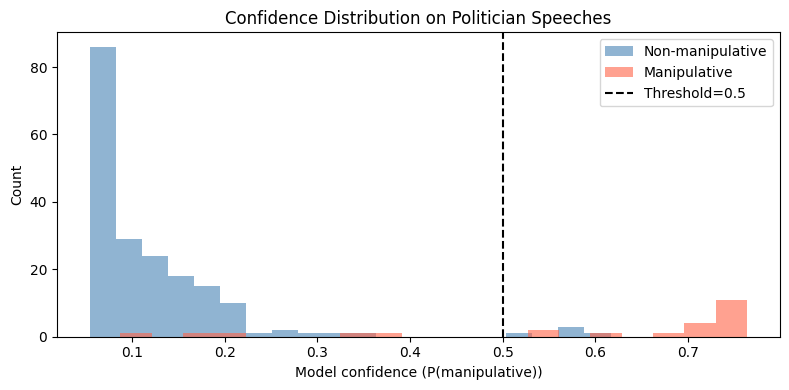

In [ ]:
# Confidence distribution plot
import matplotlib.pyplot as plt

manip_probs    = [speech_probs[i] for i in range(len(speech_labels)) if speech_labels[i] == 1]
nonmanip_probs = [speech_probs[i] for i in range(len(speech_labels)) if speech_labels[i] == 0]

plt.figure(figsize=(8,4))
plt.hist(nonmanip_probs, bins=20, alpha=0.6, label='Non-manipulative', color='steelblue')
plt.hist(manip_probs, bins=20, alpha=0.6, label='Manipulative', color='tomato')
plt.axvline(0.5, color='black', linestyle='--', label='Threshold=0.5')
plt.xlabel('Model confidence (P(manipulative))')
plt.ylabel('Count')
plt.title('Confidence Distribution on Politician Speeches')
plt.legend()
plt.tight_layout()
plt.savefig('confidence_dist.png', dpi=150)
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'Macro F1':>10}")
print("-" * 45)
for thresh in [0.50, 0.40, 0.35, 0.25, 0.15]:
    preds = (speech_probs >= thresh).astype(int)
    p = precision_score(speech_labels, preds, pos_label=1, zero_division=0)
    r = recall_score(speech_labels, preds, pos_label=1, zero_division=0)
    f = f1_score(speech_labels, preds, average='macro', zero_division=0)
    print(f"{thresh:>10.2f} {p:>10.3f} {r:>10.3f} {f:>10.3f}")

 Threshold  Precision     Recall   Macro F1
---------------------------------------------
      0.50      0.792      0.792      0.883
      0.40      0.792      0.792      0.883
      0.35      0.769      0.833      0.887
      0.25      0.677      0.875      0.865
      0.15      0.333      0.958      0.678


In [ ]:
fp = [(speech_probs[i], speech_texts[i], speech_meta[i])
      for i in range(len(speech_labels))
      if speech_labels[i] == 0 and speech_preds[i] == 1]
fp.sort(reverse=True)

print(f"Total false positives: {len(fp)}")
print("\n── Top 10 False Positives ──")
for prob, text, (president, title) in fp[:10]:
    print(f"\n[conf={prob:.3f}] {president} — {title}")
    print(f"  \"{text[:150]}\"")

Total false positives: 5

── Top 10 False Positives ──

[conf=0.616] Donald Trump — July 24, 2017: Speech at the Boy Scout Jamboree 
  "to know about the word “momentum.” But the big thing, never quit, never give up; do something you love. When you do something you love as a Scout, I s"

[conf=0.574] Barack Obama — September 10, 2013: Address to the Nation on Syria
  "the dangers of retaliation.&nbsp; We don’t dismiss any threats, but the Assad regime does not have the ability to seriously threaten our military.&nbs"

[conf=0.571] Harry S. Truman — March 29, 1952: Jefferson-Jackson Day Dinner
  "Republicans make a great whoop and holier about the honesty of Federal employees, but they are usually the first to show up in a Government office ask"

[conf=0.567] Barack Obama — January 10, 2017: Farewell Address to the Nation
  "And that's not easy to do. For too many of us, it's become safer to retreat into our own bubbles, whether in our neighborhoods or on college campuses "

[conf=0.505